In [3]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


Generated Grid:


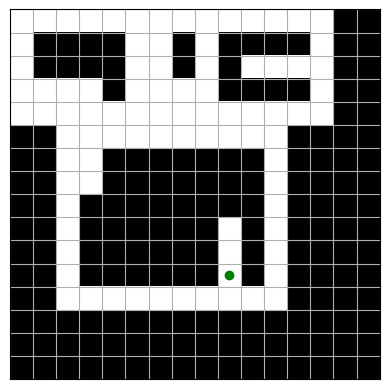

In [4]:
# Generate a random grid
gen = WRPDataGenerator(16, 16)
grid, start = gen.generate_valid_grid(density=5)
print("Generated Grid:")

plot_grid(grid, start)

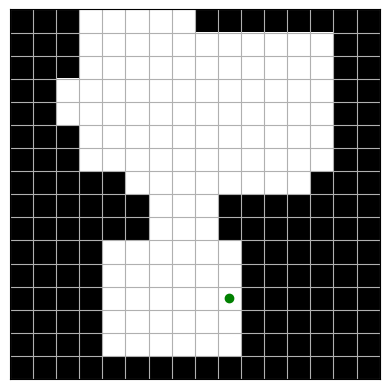

In [5]:
grid, start = gen.generate_simple_polygon_grid(density=0.2)
plot_grid(grid, start)

In [6]:
# grid = np.array(
#     [[0, 0, 0, 0, 0],
#         [1, 1, 0, 1, 1],
#         [0, 0, 0, 0, 0],
#         [0, 1, 1, 1, 0],
#         [0, 1, 0, 0, 0]])
# start = (4, 0)

# grid = np.array([
#     [0,0,0,0,0,0],
#     [1,1,0,0,1,0],
#     [0,0,0,0,1,0],
#     [0,1,0,0,1,0],
#     [0,1,0,0,1,0],
#     [1,1,0,0,1,1],
#     [0,0,0,0,0,0]
# ])
# start = (6, 0)
# plot_grid(grid)

In [7]:
solver_opt = WRPSolverTSPJF(grid, start)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)

print("Optimized Path Length:", len(path_opt))
# solver = WRPSolver(grid, start)
# path, cnt = solve_wrp_a_star(solver)
# print("A* Path Length:", len(path))



Optimized Path Length: 19


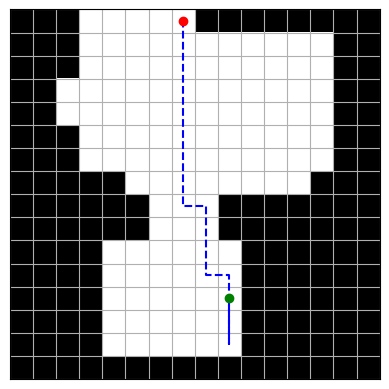

In [8]:
# plot_path(grid, path)
plot_path(grid, path_opt, start)

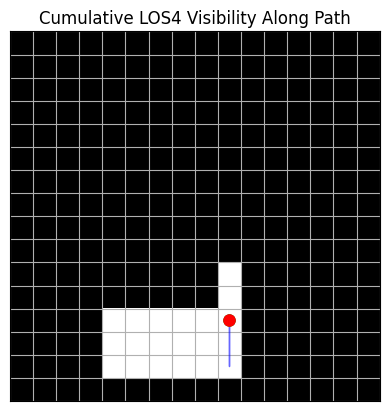

In [9]:
plot_visibility(grid, path_opt[:5], gen, False)

## Generate Data

In [9]:
# from data_generator import *
# X_train, y_train = generate_N_training_data(100)
# print("Generated training data shapes:", X_train.shape, y_train.shape)
# # save_data_to_disk(X_train, y_train, "data/wrp_data_16x16_500_samples_train.pt")

In [10]:
# X_test, y_test = generate_N_training_data(20)
# print("Generated test data shapes:", X_test.shape, y_test.shape)
# # save_data_to_disk(X_test, y_test, "data/wrp_data_16x16_20_samples_SP_test.pt")


## Load Data and Train

In [10]:

# X_train, y_train = load_data_from_disk("data/wrp_data_16x16_500_samples_train.pt", sample = 0.5, device=DEVICE)
X_test, y_test = load_data_from_disk("data/wrp_data_16x16_50_samples_test.pt", device=DEVICE)
x_train_n, y_train_n = load_data_from_disk("data/wrp_data_16x16_1000_samples_new_train.pt", device=DEVICE)
X_test_n, y_test_n = load_data_from_disk("data/wrp_data_16x16_100_samples_new_test.pt", device=DEVICE)

X_train_sp, y_train_sp = load_data_from_disk("data/wrp_data_16x16_100_samples_SP_train.pt", device=DEVICE)
X_test_sp, y_test_sp = load_data_from_disk("data/wrp_data_16x16_20_samples_SP_test.pt", device=DEVICE)

X_hard, y_hard = load_data_from_disk("data/wrp_data_16x16_75_samples_hard.pt", device=DEVICE)
X_hard_sp, y_hard_sp = load_data_from_disk("data/wrp_data_16x16_75_samples_SP_hard.pt", device=DEVICE)


# X_hard_sp2, y_hard_sp2 = load_data_from_disk("data/wrp_data_16x16_50_samples_SP_hard.pt", device=DEVICE)


X_train = torch.cat([x_train_n, X_hard_sp, X_train_sp, X_hard], dim=0)
y_train = torch.cat([y_train_n, y_hard_sp, y_train_sp, y_hard], dim=0)

X_test = torch.cat([X_test_n, X_test_sp, X_test], dim=0)
y_test = torch.cat([y_test_n, y_test_sp, y_test], dim=0)
print("Combined training data shapes:", X_train.shape, y_train.shape)
print("Combined test data shapes:", X_test.shape, y_test.shape)

Loaded 2027 samples from data/wrp_data_16x16_50_samples_test.pt
X shape: (2027, 3, 16, 16) | y shape: (2027, 1, 16, 16)
Loaded 46984 samples from data/wrp_data_16x16_1000_samples_new_train.pt
X shape: (46984, 3, 16, 16) | y shape: (46984, 1, 16, 16)
Loaded 1380 samples from data/wrp_data_16x16_100_samples_new_test.pt
X shape: (1380, 3, 16, 16) | y shape: (1380, 1, 16, 16)
Loaded 2642 samples from data/wrp_data_16x16_100_samples_SP_train.pt
X shape: (2642, 3, 16, 16) | y shape: (2642, 1, 16, 16)
Loaded 515 samples from data/wrp_data_16x16_20_samples_SP_test.pt
X shape: (515, 3, 16, 16) | y shape: (515, 1, 16, 16)
Loaded 3123 samples from data/wrp_data_16x16_75_samples_hard.pt
X shape: (3123, 3, 16, 16) | y shape: (3123, 1, 16, 16)
Loaded 3134 samples from data/wrp_data_16x16_75_samples_SP_hard.pt
X shape: (3134, 3, 16, 16) | y shape: (3134, 1, 16, 16)
Combined training data shapes: torch.Size([55883, 3, 16, 16]) torch.Size([55883, 1, 16, 16])
Combined test data shapes: torch.Size([3922,

In [11]:

X_train_aug, y_train_aug = augment_data(X_train, y_train)
print(f"Augmented training data: {X_train_aug.shape}, {y_train_aug.shape}  (8x original)")

Augmented training data: torch.Size([447064, 3, 16, 16]), torch.Size([447064, 1, 16, 16])  (8x original)


In [12]:
model = UNet16x16(in_channels=3, out_channels=1)
dummy_input = torch.randn(1, 3, 16, 16)
output = model(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}") 

Input shape: torch.Size([1, 3, 16, 16])
Output shape: torch.Size([1, 1, 16, 16])


In [13]:


# model = UNet16x16(in_channels=3, out_channels=1)
# output = model(X_train)
# print(f"Output shape: {output.shape}")

In [14]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoftFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, epsilon=1e-7):
        super(SoftFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def forward(self, preds, targets):
        # Clamp predictions to prevent log(0) resulting in NaN
        preds = torch.clamp(preds, self.epsilon, 1.0 - self.epsilon)

        # Standard Cross Entropy for continuous targets
        ce_loss_pos = -targets * torch.log(preds)
        ce_loss_neg = -(1.0 - targets) * torch.log(1.0 - preds)

        # Apply the Focal Loss modulating factors
        focal_term_pos = torch.pow(1.0 - preds, self.gamma)
        focal_term_neg = torch.pow(preds, self.gamma)

        # Combine and apply class balancing (alpha)
        loss_pos = self.alpha * focal_term_pos * ce_loss_pos
        loss_neg = (1.0 - self.alpha) * focal_term_neg * ce_loss_neg

        loss = loss_pos + loss_neg
        return loss.mean()

def train_unet(X_train, y_train, X_val, y_val, model, num_epochs=50, batch_size=32, lr=1e-3, device=DEVICE):
    # Setup Device
    print(f"Training on: {device}")
    model = model.to(device)

    # Setup DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Loss and Optimizer
    criterion = SoftFocalLoss(alpha=0.75, gamma=2.0) # High alpha to heavily weight the path pixels
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # Cosine Annealing scheduler helps the model settle into local minima smoothly
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            preds = model(batch_X)
            
            # Loss calculation
            loss = criterion(preds, batch_y)
            
            # Backward and optimize
            loss.backward()
            
            # Gradient clipping prevents exploding gradients in deep U-Nets
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

            # Calculate Top-1 Action Accuracy
            # Flatten to (Batch, 256)
            preds_flat = preds.view(batch_X.size(0), -1)
            targets_flat = batch_y.view(batch_y.size(0), -1)
            
            # Find the index of the max probability
            pred_actions = preds_flat.argmax(dim=1)
            true_actions = targets_flat.argmax(dim=1)
            
            train_correct += (pred_actions == true_actions).sum().item()
            train_total += batch_X.size(0)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = model(batch_X)
                
                loss = criterion(preds, batch_y)
                val_loss += loss.item() * batch_X.size(0)

                preds_flat = preds.view(batch_X.size(0), -1)
                targets_flat = batch_y.view(batch_y.size(0), -1)
                
                pred_actions = preds_flat.argmax(dim=1)
                true_actions = targets_flat.argmax(dim=1)
                
                val_correct += (pred_actions == true_actions).sum().item()
                val_total += batch_X.size(0)

        # Epoch Metrics
        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"LR: {scheduler.get_last_lr()[0]:.6f} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # # Save the best model strictly based on Top-1 Action Accuracy
        # if val_acc > best_val_acc:
        #     best_val_acc = val_acc
        #     torch.save(model.state_dict(), 'best_wrp_unet.pth')
        #     print(f"--> Saved New Best Model (Acc: {val_acc:.4f})")

        scheduler.step()

    print("Training Complete.")
    return model

In [15]:
model = UNet16x16(in_channels=3, out_channels=1)
trained_model = train_unet(X_train_aug, y_train_aug, X_test, y_test, model, num_epochs=5)

Training on: mps
Epoch [1/5] LR: 0.001000 | Train Loss: 0.0003 | Train Acc: 0.8501 | Val Loss: 0.0003 | Val Acc: 0.8664
Epoch [2/5] LR: 0.000905 | Train Loss: 0.0002 | Train Acc: 0.8945 | Val Loss: 0.0002 | Val Acc: 0.8911
Epoch [3/5] LR: 0.000655 | Train Loss: 0.0002 | Train Acc: 0.9131 | Val Loss: 0.0002 | Val Acc: 0.8909
Epoch [4/5] LR: 0.000345 | Train Loss: 0.0001 | Train Acc: 0.9310 | Val Loss: 0.0002 | Val Acc: 0.9011
Epoch [5/5] LR: 0.000095 | Train Loss: 0.0001 | Train Acc: 0.9495 | Val Loss: 0.0003 | Val Acc: 0.8965
Training Complete.


In [18]:
# trained_model.to("cpu")  # Move to CPU before saving for broader compatibility
# torch.save(trained_model.state_dict(), "model_16x16_ResAttARUnet.pth")
trained_model = UNet16x16()
model_state_dict = torch.load("model_16x16_ResAttARUnet_2x.pth")
trained_model.load_state_dict(model_state_dict)
trained_model.to(DEVICE)

UNet16x16(
  (inc): ResidualConv(
    (conv1): Conv2d(5, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(5, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (down1): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): ResidualConv(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(

In [19]:
trained_model.eval()
with torch.no_grad():
    output = trained_model(X_test.to(DEVICE)).cpu()

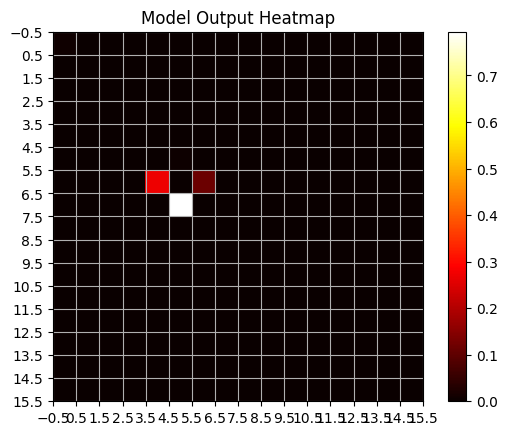

In [20]:
plot_output_tensor(output[10])

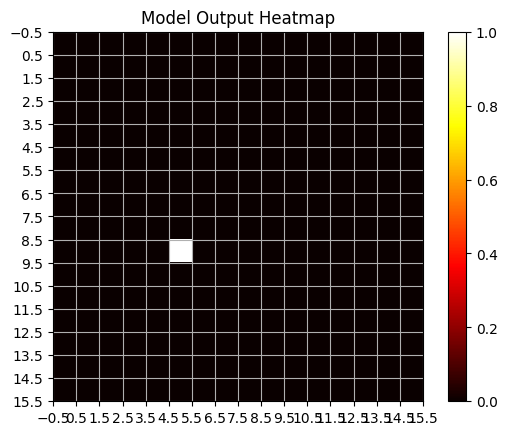

In [21]:
plot_output_tensor(y_test[12])

## Testing

In [ ]:
import torch
import numpy as np
import heapq


def predict_path_greedy(model, grid, start, max_steps=50, verbose=False):
    model.eval()
    model_device = next(model.parameters()).device
    path = [start]
    current_cell = start
    H, W = grid.shape
    data = []
    
    visited_counts = np.zeros((H, W))
    visited_counts[start[0], start[1]] = 1
    grid_tensor = torch.from_numpy(grid).float().unsqueeze(0)

    for step in range(max_steps):
        current_cell_map = torch.zeros_like(grid_tensor)
        current_cell_map[0, current_cell[0], current_cell[1]] = 1.0
        
        visibility = get_LOS4_visibility_map(grid, path)
        unseen_map_numpy = (1.0 - visibility) * (1.0 - grid)
        
        if np.sum(unseen_map_numpy) == 0:
            if verbose: 
                print(f"Goal reached in {step} steps!")
            break
            
        unseen_map = torch.from_numpy(unseen_map_numpy).float().unsqueeze(0)
        input_tensor = torch.stack([grid_tensor, current_cell_map, unseen_map], dim=1).to(model_device)
        data.append(input_tensor.cpu())

        with torch.no_grad():
            output = model(input_tensor)[0, 0]
        
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        best_next_cell = None
        highest_score = -float('inf')
        r, c = current_cell
        
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and grid[nr, nc] == 0:
                prob = output[nr, nc].item()
                penalty = visited_counts[nr, nc] * 0.2  # Penalize revisiting cells
                score = prob - penalty
                if score > highest_score:
                    highest_score = score
                    best_next_cell = (nr, nc)
        
        if best_next_cell is None:
            if verbose:
                print("Trapped! No valid moves.")
            break
            
        path.append(best_next_cell)
        current_cell = best_next_cell
        visited_counts[current_cell[0], current_cell[1]] += 1

    if len(data) == 0:
        return path, torch.empty(0)
    return path, torch.cat(data, dim=0)

import torch
import numpy as np
import heapq

def neural_guided_search(model, grid, start, lambda_weight=2.0, max_expansions=5000):
    model.eval()
    model_device = next(model.parameters()).device
    H, W = grid.shape

    free_space = set((r, c) for r in range(H) for c in range(W) if grid[r, c] == 0)
    
    # Using your get_LOS4_visibility_map function
    init_vis = get_LOS4_visibility_map(grid, [start])
    init_seen = set((r, c) for r in range(H) for c in range(W) if init_vis[r, c] == 1)
    init_unseen = frozenset(free_space - init_seen)

    if not init_unseen:
        return [start]

    pq = []
    tie_breaker = 0  # FIX 2: Prevents frozenset comparison crashes
    
    # Format: (f_score, tie_breaker, cumulative_cost, real_steps, current_cell, path, unseen_set)
    heapq.heappush(pq, (0.0, tie_breaker, 0.0, 0, start, [start], init_unseen))
    
    visited = {(start, init_unseen): 0.0}
    expansions = 0
    best_path = [start]
    best_unseen_count = len(init_unseen)

    while pq:
        # Pop based on lowest f_score
        f_score, _, cumulative_cost, g, current_cell, path, unseen_set = heapq.heappop(pq)
        expansions += 1

        if len(unseen_set) < best_unseen_count:
            best_unseen_count = len(unseen_set)
            best_path = path

        # I recommend bumping this to 15000 just to give the search breathing room
        if expansions > 15000:
            print("Failed: Hit max expansions. Returning best path.")
            return best_path

        if len(unseen_set) == 0:
            # print(f"Goal Reached! Path length: {g}, Nodes Expanded: {expansions}")
            return path

        grid_tensor = torch.from_numpy(grid).float().unsqueeze(0)
        current_cell_map = torch.zeros((1, H, W), dtype=torch.float32)
        current_cell_map[0, current_cell[0], current_cell[1]] = 1.0
        unseen_map_tensor = torch.zeros((1, H, W), dtype=torch.float32)
        for ur, uc in unseen_set:
            unseen_map_tensor[0, ur, uc] = 1.0

        input_tensor = torch.stack([grid_tensor, current_cell_map, unseen_map_tensor], dim=1).to(model_device)
        
        with torch.no_grad():
            output = model(input_tensor)[0, 0]

        r, c = current_cell
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and grid[nr, nc] == 0:
                next_cell = (nr, nc)
                new_g = g + 1
                new_path = path + [next_cell]
                new_vis = get_LOS4_visibility_map(grid, new_path)
                new_seen = set((vr, vc) for vr in range(H) for vc in range(W) if new_vis[vr, vc] == 1)
                new_unseen = frozenset(free_space - new_seen)
                new_state = (next_cell, new_unseen)

                prob = output[nr, nc].item()
                epsilon = 1e-6
                
                # 1. Cost to reach this node (g)
                edge_penalty = 1.0 - (lambda_weight * np.log(prob + epsilon))
                new_cumulative_cost = cumulative_cost + edge_penalty

                # 2. Heuristic: Cost to goal (h)
                # Every unseen cell requires roughly ~0.1 steps of effort to reveal depending on the grid.
                # You can tune this heuristic_weight.
                heuristic_weight = 0.5 
                h = len(new_unseen) * heuristic_weight
                
                # 3. Total A* Score (f = g + h)
                new_f = new_cumulative_cost + h

                if new_state not in visited or new_cumulative_cost < visited[new_state]:
                    visited[new_state] = new_cumulative_cost
                    tie_breaker += 1
                    # Push using the new_f score
                    heapq.heappush(pq, (new_f, tie_breaker, new_cumulative_cost, new_g, next_cell, new_path, new_unseen))

    print("Search exhausted without full coverage.")
    return best_path


import torch
import numpy as np
import heapq

def neural_guided_search2(model, grid, start, lambda_weight=2.0, max_expansions=5000):
    model.eval()
    model_device = next(model.parameters()).device
    H, W = grid.shape

    free_space = set((r, c) for r in range(H) for c in range(W) if grid[r, c] == 0)
    
    # Using your get_LOS4_visibility_map function
    init_vis = get_LOS4_visibility_map(grid, [start])
    init_seen = set((r, c) for r in range(H) for c in range(W) if init_vis[r, c] == 1)
    init_unseen = frozenset(free_space - init_seen)

    if not init_unseen:
        return [start]

    pq = []
    tie_breaker = 0  # FIX 2: Prevents frozenset comparison crashes
    
    # Format: (f_score, tie_breaker, cumulative_cost, real_steps, current_cell, path, unseen_set)
    heapq.heappush(pq, (0.0, tie_breaker, 0.0, 0, start, [start], init_unseen))
    
    # --- PATCH 1: Initialize visited to track integer physical steps (g) ---
    visited = {(start, init_unseen): 0}
    
    expansions = 0
    best_path = [start]
    best_unseen_count = len(init_unseen)

    while pq:
        # Pop based on lowest f_score
        f_score, _, cumulative_cost, g, current_cell, path, unseen_set = heapq.heappop(pq)
        expansions += 1

        if len(unseen_set) < best_unseen_count:
            best_unseen_count = len(unseen_set)
            best_path = path

        # I recommend bumping this to 15000 just to give the search breathing room
        if expansions > 15000:
            print("Failed: Hit max expansions. Returning best path.")
            return best_path

        if len(unseen_set) == 0:
            # print(f"Goal Reached! Path length: {g}, Nodes Expanded: {expansions}")
            return path

        grid_tensor = torch.from_numpy(grid).float().unsqueeze(0)
        current_cell_map = torch.zeros((1, H, W), dtype=torch.float32)
        current_cell_map[0, current_cell[0], current_cell[1]] = 1.0
        unseen_map_tensor = torch.zeros((1, H, W), dtype=torch.float32)
        for ur, uc in unseen_set:
            unseen_map_tensor[0, ur, uc] = 1.0

        input_tensor = torch.stack([grid_tensor, current_cell_map, unseen_map_tensor], dim=1).to(model_device)
        
        with torch.no_grad():
            output = model(input_tensor)[0, 0]

        r, c = current_cell
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and grid[nr, nc] == 0:
                next_cell = (nr, nc)
                new_g = g + 1
                new_path = path + [next_cell]
                new_vis = get_LOS4_visibility_map(grid, new_path)
                new_seen = set((vr, vc) for vr in range(H) for vc in range(W) if new_vis[vr, vc] == 1)
                new_unseen = frozenset(free_space - new_seen)
                new_state = (next_cell, new_unseen)

                prob = output[nr, nc].item()
                epsilon = 1e-6
                
                # 1. Cost to reach this node (g)
                edge_penalty = 1.0 - (lambda_weight * np.log(prob + epsilon))
                new_cumulative_cost = cumulative_cost + edge_penalty

                # 2. Heuristic: Cost to goal (h)
                # Every unseen cell requires roughly ~0.1 steps of effort to reveal depending on the grid.
                # You can tune this heuristic_weight.
                heuristic_weight = 0.5 
                h = len(new_unseen) * heuristic_weight
                
                # 3. Total A* Score (f = g + h)
                new_f = new_cumulative_cost + h

                # --- PATCH 2: Check visited dictionary against physical steps (new_g) ---
                if new_state not in visited or new_g < visited[new_state]:
                    
                    # --- PATCH 3: Store physical steps in visited dictionary ---
                    visited[new_state] = new_g
                    
                    tie_breaker += 1
                    # Push using the new_f score
                    heapq.heappush(pq, (new_f, tie_breaker, new_cumulative_cost, new_g, next_cell, new_path, new_unseen))

    print("Search exhausted without full coverage.")
    return best_path

In [23]:
def check_test_data_is_not_in_train(X_train, X_test):
    """Checks if any test sample is identical to a training sample."""
    cnt = 0
    train_set = set(x.tobytes() for x in X_train.numpy())
    for x_test in X_test.numpy():
        if x_test.tobytes() in train_set:
            cnt += 1
            # print("Found a test sample that is identical to a training sample!")
    if cnt == 0:
        print("No test samples are identical to training samples.")
        return False
    else:
        print(f"Total {cnt} test samples are identical to training samples.")
        return True

check_test_data_is_not_in_train(X_train_aug.cpu(), X_test.cpu())

def check_if_this_grid_is_in_train(X_train, grid):
    """Checks if the given grid is identical to any training sample."""
    grid_bytes = grid.tobytes()
    for x in X_train.numpy():
        if x[0].tobytes() == grid_bytes:
            print("Found a test grid that is identical to a training grid!")
            return True
    # print("No test grids are identical to training grids.")
    return False
check_if_this_grid_is_in_train(X_train_aug.cpu(), grid)

Total 23 test samples are identical to training samples.


False

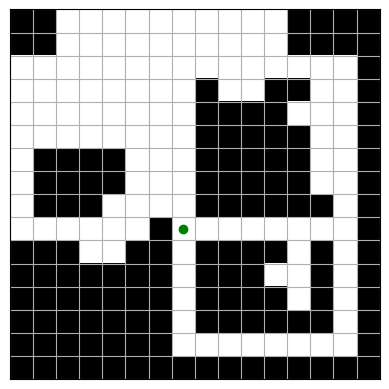

False

In [152]:
grid, start = gen.generate_valid_grid(density = 5)
# grid, start = gen.generate_simple_polygon_grid(density=0.2)


# grid = np.zeros((16, 16))  # Empty grid with no obstacles
# grid[16//2][16//2] = 1
# grid[16//2- 1][16//2] = 1
# grid[16//2+1][16//2] = 1
# grid[16//2][16//2- 1] = 1
# grid[16//2][16//2+1] = 1

# start = (0, 0)  # Starting at the top-left corner
plot_grid(grid, start)  # Plot the grid from the first channel of the input

check_if_this_grid_is_in_train(X_train_aug.cpu(), grid)

Goal reached in 53 steps!
Predicted Path Length: 54


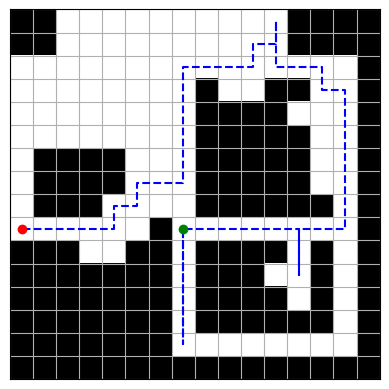

Goal Reached! Path length: 51, Nodes Expanded: 1214
[(9, 7), (10, 7), (11, 7), (12, 7), (13, 7), (14, 7), (13, 7), (12, 7), (11, 7), (10, 7), (9, 7), (8, 7), (8, 6), (8, 5), (8, 4), (9, 4), (9, 3), (9, 2), (9, 1), (9, 0), (8, 0), (7, 0), (6, 0), (5, 0), (5, 1), (5, 2), (5, 3), (4, 3), (3, 3), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (3, 13), (4, 13), (5, 13), (6, 13), (7, 13), (7, 14), (8, 14), (9, 14), (9, 13), (9, 12), (10, 12), (11, 12)]
Predicted Path Length: 52


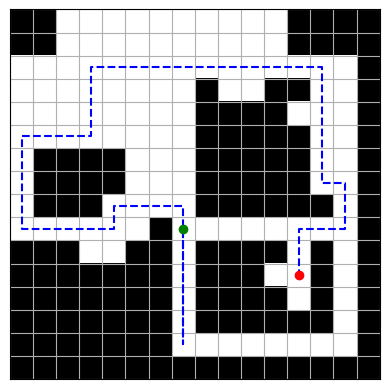

Goal Reached! Path length: 51, Nodes Expanded: 878
[(9, 7), (10, 7), (11, 7), (12, 7), (13, 7), (14, 7), (13, 7), (12, 7), (11, 7), (10, 7), (9, 7), (8, 7), (8, 6), (8, 5), (9, 5), (9, 4), (9, 3), (9, 2), (9, 1), (9, 0), (8, 0), (7, 0), (6, 0), (5, 0), (5, 1), (5, 2), (5, 3), (4, 3), (3, 3), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (3, 13), (4, 13), (5, 13), (6, 13), (7, 13), (7, 14), (8, 14), (9, 14), (9, 13), (9, 12), (10, 12), (11, 12)]
Predicted Path Length: 52


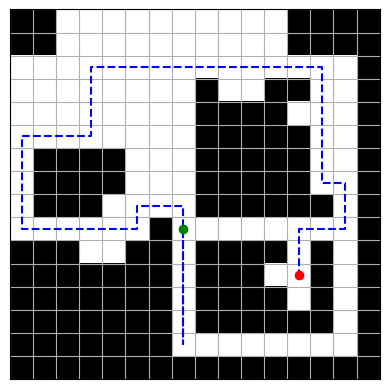

In [153]:
path_pred_line, data_t = predict_path_greedy(trained_model, grid, start, max_steps=100, verbose=True)
print("Predicted Path Length:", len(path_pred_line))
plot_path(grid, path_pred_line)
path_pred_line = neural_guided_search(trained_model, grid, start)
print(path_pred_line)
print("Predicted Path Length:", len(path_pred_line))
plot_path(grid, path_pred_line)
path_pred_line = neural_guided_search2(trained_model, grid, start)
print(path_pred_line)
print("Predicted Path Length:", len(path_pred_line))
plot_path(grid, path_pred_line)

Optimized Path Length: 51


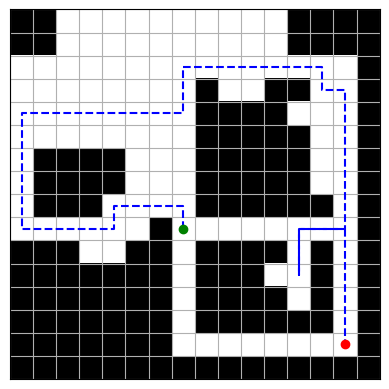

In [154]:
solver_opt = WRPSolverTSPJF(grid, start)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)
print("Optimized Path Length:", len(path_opt))
plot_path(grid, path_opt, start)

In [ ]:
# data_one, labels_one = generate_training_data(grid, path_opt)
# print("Single sample data shapes:", data_one.shape, labels_one.shape)

# trained_model.eval()
# with torch.no_grad():
#     output = trained_model(data_one.to(DEVICE)).cpu()

# path_pred_line = get_path_from_y_labels(output)
# print("Predicted Path from Single Sample:", path_pred_line)
# print("Predicted Path Length from Single Sample:", len(path_pred_line))
# plot_path(grid, path_pred_line, start)

Total 23 test samples are identical to training samples.


False

## Evaluating as a Whole

In [117]:
def evaluate_model_on_random_grids(model, polygon_type = "holes", user_neural_search=False, num_samples=5):
     model.eval()
     grid_size = (16, 16)
     gt_path_lengths = []
     pred_path_lengths = []
     pred_path_lengths_search = []

     for i in tqdm(range(num_samples)):
          gen = WRPDataGenerator(*grid_size)
          grid, start = None, None
          if polygon_type == "holes":
               grid, start = gen.generate_valid_grid(density=5)
          elif polygon_type == "simple_polygon":
               grid, start = gen.generate_simple_polygon_grid(density=0.2)
          # grid, start = gen.generate_valid_grid(density=0.2)
          # grid, start = gen.generate_simple_polygon_grid(density=0.2)

          solver_opt = WRPSolverTSPJF(grid, start)
          path_opt, _ = solve_wrp_tsp_jf(solver_opt)

          path_pred_line, _ = predict_path_greedy(model, grid, start, max_steps=100)
          if (user_neural_search):
               path_pred_line_search = neural_guided_search2(model, grid, start)

          gt_path_lengths.append(len(path_opt))
          pred_path_lengths.append(len(path_pred_line))
          
          if user_neural_search: 
               pred_path_lengths_search.append(len(path_pred_line_search))

     rmse = np.sqrt(np.mean([(gt - pred) ** 2 for gt, pred in zip(gt_path_lengths, pred_path_lengths)]))
     print(f"\nAverage Ground Truth Path Length: {np.mean(gt_path_lengths):.2f}")
     print(f"Average Predicted Path Length: {np.mean(pred_path_lengths):.2f}")
     print(f"Root Mean Squared Error in Path Lengths: {rmse:.2f}") 

     print("Ground Truth Path Length:  ", gt_path_lengths)
     print("Model Predict Path Length: ", pred_path_lengths)
     if user_neural_search:
          print("Neural Search Path Length: ", pred_path_lengths_search)
          return np.array(gt_path_lengths), np.array(pred_path_lengths), np.array(pred_path_lengths_search)
     return np.array(gt_path_lengths), np.array(pred_path_lengths), None


In [ ]:
gt_path_lengths1, pred_path_lengths1, pred_path_lengths_search1 = evaluate_model_on_random_grids(trained_model, "simple_polygon",True,  num_samples=100)


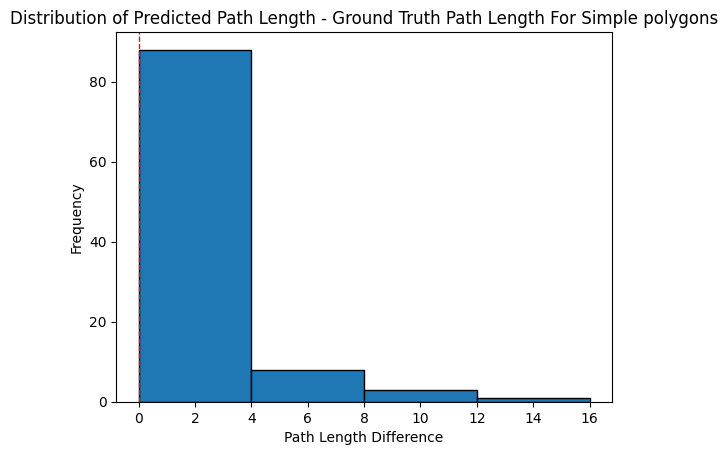

In [145]:
path_len_diff = np.minimum(pred_path_lengths1, pred_path_lengths_search1) - gt_path_lengths1
max_diff = np.max(path_len_diff)
# path_len_diff = np.array([i if i >= 0 else max_diff + 1 for i in path_len_diff])
#bin width of 5 
step = 4
plt.hist(path_len_diff, edgecolor='black', bins=np.arange(path_len_diff.min(), path_len_diff.max() + step, step))
plt.title("Distribution of Predicted Path Length - Ground Truth Path Length For Simple polygons")
plt.xlabel("Path Length Difference")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.show()

In [ ]:


gt_path_lengths, pred_path_lengths, pred_path_lengths_search = evaluate_model_on_random_grids(trained_model, "holes", True, num_samples=100)

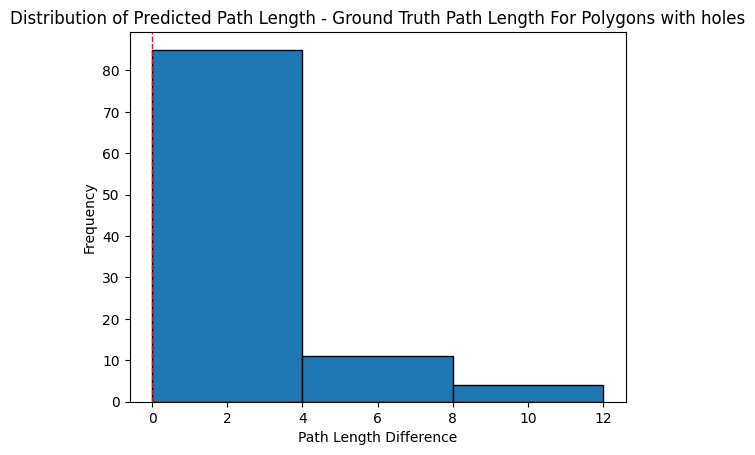

In [150]:
path_len_diff = np.minimum(pred_path_lengths, pred_path_lengths_search) - gt_path_lengths
max_diff = np.max(path_len_diff)
path_len_diff = np.array([i if i >= 0 else max_diff + 1 for i in path_len_diff])
#bin width of 5 
step = 4
plt.hist(path_len_diff, edgecolor='black', bins=np.arange(path_len_diff.min(), path_len_diff.max() + step, step))
plt.title("Distribution of Predicted Path Length - Ground Truth Path Length For Polygons with holes")
plt.xlabel("Path Length Difference")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.show()

In [97]:

#cretae dataset of n samples where model is above threshold and the resiudal is > threshold
def generate_n_samples_where_model_is_above_threshold(num_samples, threshold = 10):
    X_list = []
    y_list = []
    for _ in tqdm(range(num_samples)):
        # grid, start = gen.generate_valid_grid(density=0.2)
        grid, start = gen.generate_simple_polygon_grid(density=0.2)
        pred_path_length = len(predict_path_greedy(trained_model, grid, start, max_steps=100)[0])
        path_opt, _ = solve_wrp_tsp_jf(WRPSolverTSPJF(grid, start))
        gt_path_length = len(path_opt)
        if pred_path_length - gt_path_length > threshold:
            X, y = generate_training_data(grid, path_opt)
            X_list.append(X)
            y_list.append(y)
    return torch.cat(X_list), torch.cat(y_list) 


X_train_hard, y_train_hard = generate_n_samples_where_model_is_above_threshold(1000)

100%|██████████| 1000/1000 [18:57<00:00,  1.14s/it] 


In [100]:
X_train_hard.shape, y_train_hard.shape

(torch.Size([3134, 3, 16, 16]), torch.Size([3134, 1, 16, 16]))

In [ ]:
# save_data_to_disk(X_train_hard_x, y_train_hard, "data/wrp_data_16x16_75_samples_SP_hard.pt")


Saved 3134 samples to data/wrp_data_16x16_75_samples_SP_hard.pt
X shape: (3134, 3, 16, 16) | y shape: (3134, 1, 16, 16)


'data/wrp_data_16x16_75_samples_SP_hard.pt'

In [99]:
3134/40

78.35